In [ ]:
!wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
!tar -xzf mmseqs-linux-avx2.tar.gz
!cp mmseqs/bin/mmseqs /usr/local/bin/
!mmseqs version

# Download the two FASTA datasets from GitHub
!wget -q https://raw.githubusercontent.com/sajjadrezvani/SigPep-LB2/main/data/raw/positive.fasta
!wget -q https://raw.githubusercontent.com/sajjadrezvani/SigPep-LB2/main/data/raw/negative.fasta

d401e78c2d18a822cdb1527d7464a043f6035a15


In [7]:
# 1. Clean workspace
!rm -rf tmp_pos tmp_neg
!mkdir -p tmp_pos tmp_neg

# ==============================================================================
# NEGATIVE DATASET: Explicit connected-component clustering
# ==============================================================================
# Create sequence DB
!mmseqs createdb negative.fasta tmp_neg/neg_db

# Compute all pairwise alignments directly (avoids linclust)
!mmseqs search tmp_neg/neg_db tmp_neg/neg_db tmp_neg/aln tmp_neg/work \
    --min-seq-id 0.3 -c 0.4 --cov-mode 0

# Cluster alignments using connected components (--cluster-mode 1)
!mmseqs clust tmp_neg/neg_db tmp_neg/aln tmp_neg/neg_clu \
    --cluster-mode 1

# Extract representatives to FASTA and TSV
!mmseqs createsubdb tmp_neg/neg_clu tmp_neg/neg_db tmp_neg/neg_rep
!mmseqs convert2fasta tmp_neg/neg_rep neg_clustered_rep_seq.fasta
!mmseqs createtsv tmp_neg/neg_db tmp_neg/neg_db tmp_neg/neg_clu neg_clustered.tsv

# ==============================================================================
# POSITIVE DATASET: Explicit connected-component clustering
# ==============================================================================
# Create sequence DB
!mmseqs createdb positive.fasta tmp_pos/pos_db

# Compute all pairwise alignments directly
!mmseqs search tmp_pos/pos_db tmp_pos/pos_db tmp_pos/aln tmp_pos/work \
    --min-seq-id 0.3 -c 0.4 --cov-mode 0

# Cluster alignments using connected components (--cluster-mode 1)
!mmseqs clust tmp_pos/pos_db tmp_pos/aln tmp_pos/pos_clu \
    --cluster-mode 1

# Extract representatives to FASTA and TSV
!mmseqs createsubdb tmp_pos/pos_clu tmp_pos/pos_db tmp_pos/pos_rep
!mmseqs convert2fasta tmp_pos/pos_rep pos_clustered_rep_seq.fasta
!mmseqs createtsv tmp_pos/pos_db tmp_pos/pos_db tmp_pos/pos_clu pos_clustered.tsv

createdb negative.fasta tmp_neg/neg_db 

MMseqs Version:                    	d401e78c2d18a822cdb1527d7464a043f6035a15
Database type                      	0
Shuffle input database             	true
Createdb mode                      	0
Write lookup file                  	1
Offset of numeric ids              	0
Threads                            	2
Compressed                         	0
Mask residues                      	0
Mask residues probability          	0.9
Mask lower case residues           	0
Mask lower letter repeating N times	0
Use GPU                            	0
Verbosity                          	3

Converting sequences
[19494] 0s 50ms
Time for merging to neg_db_h: 0h 0m 0s 6ms
Time for merging to neg_db: 0h 0m 0s 14ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 103ms
Create directory tmp_neg/work
search tmp_neg/neg_db tmp_neg/neg_db tmp_neg/aln tmp_neg/work --min-seq-id 0.3 -c 0.4 --cov-mode 0 

MMseqs Version:                        	d401e78c2d18a822cdb1527d7464

In [8]:
import re
import pandas as pd

def extract_accession(header_str: str) -> str:
    """Extracts standard UniProt accession (e.g., P12345, Q9Y261) or falls back to first token."""
    text = str(header_str).strip().lstrip(">")
    match = re.search(r'([O,P,Q][0-9][A-Z,0-9]{3}[0-9]|[A-N,R-Z][0-9]([A-Z][A-Z,0-9]{2}[0-9]){1,2})', text)
    if match:
        return match.group(1)
    if "|" in text:
        parts = text.split("|")
        return parts[1] if len(parts) > 1 and parts[0] in ("sp", "tr") else parts[0]
    return text.split()[0]

def parse_fasta_lengths(fasta_file: str):
    """Parses FASTA file and returns a mapping of Accession -> Sequence Length."""
    lengths = {}
    current_acc = None
    current_len = 0

    with open(fasta_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current_acc:
                    lengths[current_acc] = current_len
                current_acc = extract_accession(line)
                current_len = 0
            else:
                current_len += len(line)
        if current_acc:
            lengths[current_acc] = current_len

    return lengths

def analyze_clusters(cluster_tsv: str, original_fasta: str, top_n: int = 10):
    # MMseqs2 TSV: Column 0 = Representative, Column 1 = Member sequence
    df = pd.read_csv(cluster_tsv, sep="\t", header=None, names=["Raw_Rep", "Raw_Mem"])

    # Extract clean UniProt accessions for matching
    df["Representative"] = df["Raw_Rep"].apply(extract_accession)
    df["Member"] = df["Raw_Mem"].apply(extract_accession)

    # Read sequence lengths from the FASTA file
    seq_lengths = parse_fasta_lengths(original_fasta)

    # Map sequence lengths
    df["Member_Length"] = df["Member"].map(seq_lengths)

    # Check if any mapped length is still missing
    missing_count = df["Member_Length"].isna().sum()
    if missing_count > 0:
        print(f"Warning: {missing_count} sequences could not be matched to the FASTA file.")

    # Aggregate cluster statistics
    cluster_summary = df.groupby("Representative").agg(
        Total_Sequences=("Member", "count"),
        Representative_Length=("Representative", lambda s: seq_lengths.get(s.iloc[0], "N/A")),
        Member_Accessions=("Member", list),
        Member_Lengths=("Member_Length", list)
    ).sort_values(by="Total_Sequences", ascending=False).reset_index()

    print(f"=== CLUSTERING ANALYSIS: {cluster_tsv} ===")
    print(f"Total Clusters: {len(cluster_summary)}\n")

    top_df = cluster_summary.head(top_n)
    for idx, row in top_df.iterrows():
        print(f"Rank {idx+1}:")
        print(f"  Representative ID     : {row['Representative']}")
        print(f"  Representative Length : {row['Representative_Length']} aa")
        print(f"  Cluster Size          : {row['Total_Sequences']} sequences")
        print(f"  Member IDs            : {row['Member_Accessions']}")
        print(f"  Member Lengths (aa)   : {row['Member_Lengths']}\n")

    return cluster_summary

# Run for Positive dataset
pos_summary = analyze_clusters("pos_clustered.tsv", "positive.fasta", top_n=10)

# Run for Negative dataset
neg_summary = analyze_clusters("neg_clustered.tsv", "negative.fasta", top_n=10)

=== CLUSTERING ANALYSIS: pos_clustered.tsv ===
Total Clusters: 1062

Rank 1:
  Representative ID     : Q90249
  Representative Length : 137 aa
  Cluster Size          : 102 sequences
  Member IDs            : ['Q90249', 'P45881', 'P49121', 'P24605', 'Q8AXY1', 'Q1ZY03', 'P00624', 'Q90W39', 'Q8UVU7', 'A6MEY4', 'G9I930', 'A8CG89', 'Q2PG81', 'P00593', 'A0A411EZW9', 'P06859', 'Q02471', 'P34180', 'Q2YHJ4', 'P70090', 'P31100', 'Q1RP79', 'Q2YHJ9', 'B5U6Y4', 'P0CAR9', 'P82114', 'A8CG78', 'B5U6Z2', 'P0CAS0', 'Q9PVF4', 'Q3HLQ4', 'P23028', 'P80963', 'Q8UVZ7', 'P14555', 'A8CG82', 'Q2YHJ6', 'D0UGJ0', 'A8CG86', 'P0DJN6', 'P0DJJ9', 'C0HLL2', 'P31854', 'P14424', 'P0DJN7', 'F8QN54', 'Q6EER4', 'Q6H3D2', 'Q6H3D3', 'P17935', 'Q2YHJ3', 'Q6JK69', 'Q6H3D5', 'Q2YHJ7', 'A8CG90', 'Q2YHJ2', 'A8E2V8', 'P0DJJ8', 'Q4VRI5', 'Q1RP78', 'Q7T2R1', 'Q2YHJ8', 'P20474', 'A4VBF0', 'C0HKC2', 'Q8QG87', 'P08878', 'C0HKC3', 'Q805A2', 'Q7ZTA6', 'P00592', 'F8QN53', 'P04054', 'P00625', 'P24027', 'Q2HZ28', 'Q90Y77', 'Q6H3C7', 'P0062

In [9]:
def show_bottom_clusters(cluster_summary_df, dataset_name: str, bottom_n: int = 10):
    print(f"=== 10 SMALLEST / BOTTOM-RANKED CLUSTERS: {dataset_name} ===")
    bottom_df = cluster_summary_df.tail(bottom_n).iloc[::-1].reset_index(drop=True)

    for idx, row in bottom_df.iterrows():
        print(f"\nBottom Rank {idx + 1}:")
        print(f"  Representative ID     : {row['Representative']}")
        print(f"  Representative Length : {row['Representative_Length']} aa")
        print(f"  Cluster Size          : {row['Total_Sequences']} sequence(s)")
        print(f"  Member IDs            : {row['Member_Accessions']}")
        print(f"  Member Lengths (aa)   : {row['Member_Lengths']}")

# Display bottom 10 for positive dataset
show_bottom_clusters(pos_summary, "POSITIVE DATASET", bottom_n=10)

# Display bottom 10 for negative dataset
show_bottom_clusters(neg_summary, "NEGATIVE DATASET", bottom_n=10)

=== 10 SMALLEST / BOTTOM-RANKED CLUSTERS: POSITIVE DATASET ===

Bottom Rank 1:
  Representative ID     : Q9Y2I2
  Representative Length : 539 aa
  Cluster Size          : 1 sequence(s)
  Member IDs            : ['Q9Y2I2']
  Member Lengths (aa)   : [539]

Bottom Rank 2:
  Representative ID     : Q9Y4X3
  Representative Length : 112 aa
  Cluster Size          : 1 sequence(s)
  Member IDs            : ['Q9Y4X3']
  Member Lengths (aa)   : [112]

Bottom Rank 3:
  Representative ID     : Q9Y5Q6
  Representative Length : 135 aa
  Cluster Size          : 1 sequence(s)
  Member IDs            : ['Q9Y5Q6']
  Member Lengths (aa)   : [135]

Bottom Rank 4:
  Representative ID     : Q9Y5U5
  Representative Length : 241 aa
  Cluster Size          : 1 sequence(s)
  Member IDs            : ['Q9Y5U5']
  Member Lengths (aa)   : [241]

Bottom Rank 5:
  Representative ID     : Q9Y6C2
  Representative Length : 1016 aa
  Cluster Size          : 1 sequence(s)
  Member IDs            : ['Q9Y6C2']
  Member Leng

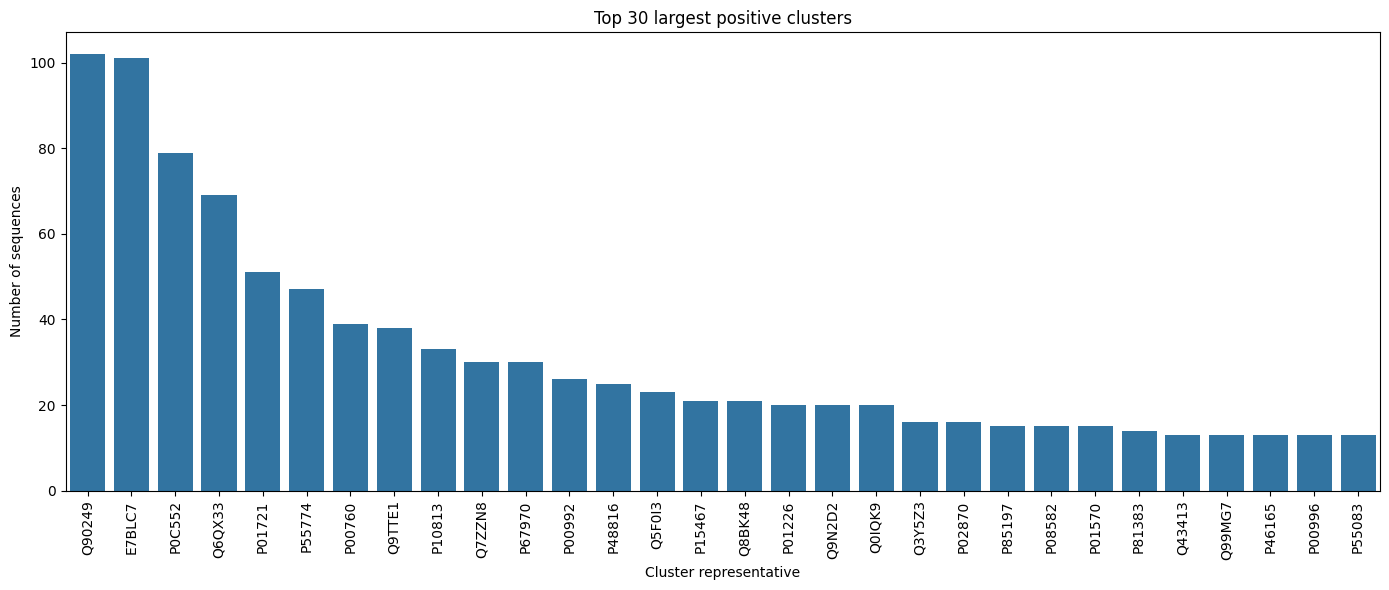

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "pos_clustered_cluster.tsv",
    sep="\t",
    header=None,
    names=["Representative", "Sequence"]
)

cluster_sizes = (
    df.groupby("Representative")
      .size()
      .sort_values(ascending=False)
      .head(30)
      .reset_index(name="Number_of_sequences")
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=cluster_sizes,
    x="Representative",
    y="Number_of_sequences"
)

plt.xticks(rotation=90)
plt.xlabel("Cluster representative")
plt.ylabel("Number of sequences")
plt.title("Top 30 largest positive clusters")
plt.tight_layout()
plt.show()

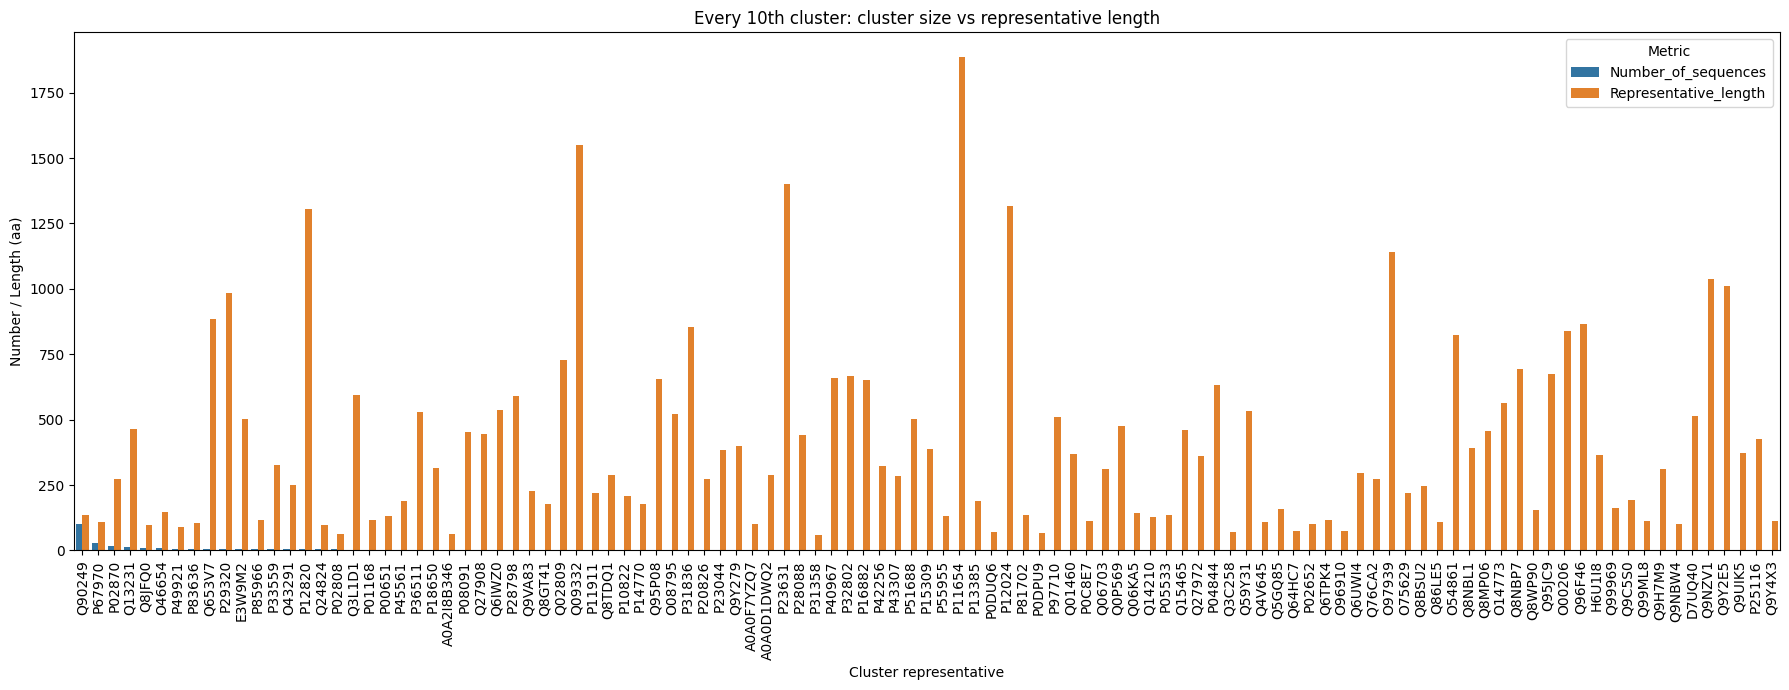

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "pos_clustered_cluster.tsv",
    sep="\t",
    header=None,
    names=["Representative", "Sequence"]
)

# Count sequences in each cluster
cluster_sizes = (
    df.groupby("Representative")
      .size()
      .reset_index(name="Number_of_sequences")
)

# Read representative sequence lengths
lengths = {}
with open("pos_clustered_rep_seq.fasta") as f:
    current_id = None
    seq = []
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if current_id:
                lengths[current_id] = len("".join(seq))
            current_id = line.split("|")[1]
            seq = []
        else:
            seq.append(line)

if current_id:
    lengths[current_id] = len("".join(seq))

# Add representative length
cluster_sizes["Representative_length"] = (
    cluster_sizes["Representative"].map(lengths)
)

# Sort by cluster size, largest first
cluster_sizes = cluster_sizes.sort_values(
    "Number_of_sequences",
    ascending=False
).reset_index(drop=True)

# Take every 10th cluster
sampled = cluster_sizes.iloc[::10].copy()

# Plot
plot_data = sampled.melt(
    id_vars="Representative",
    value_vars=["Number_of_sequences", "Representative_length"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(18, 7))
sns.barplot(
    data=plot_data,
    x="Representative",
    y="Value",
    hue="Metric"
)

plt.xlabel("Cluster representative")
plt.ylabel("Number / Length (aa)")
plt.title("Every 10th cluster: cluster size vs representative length")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

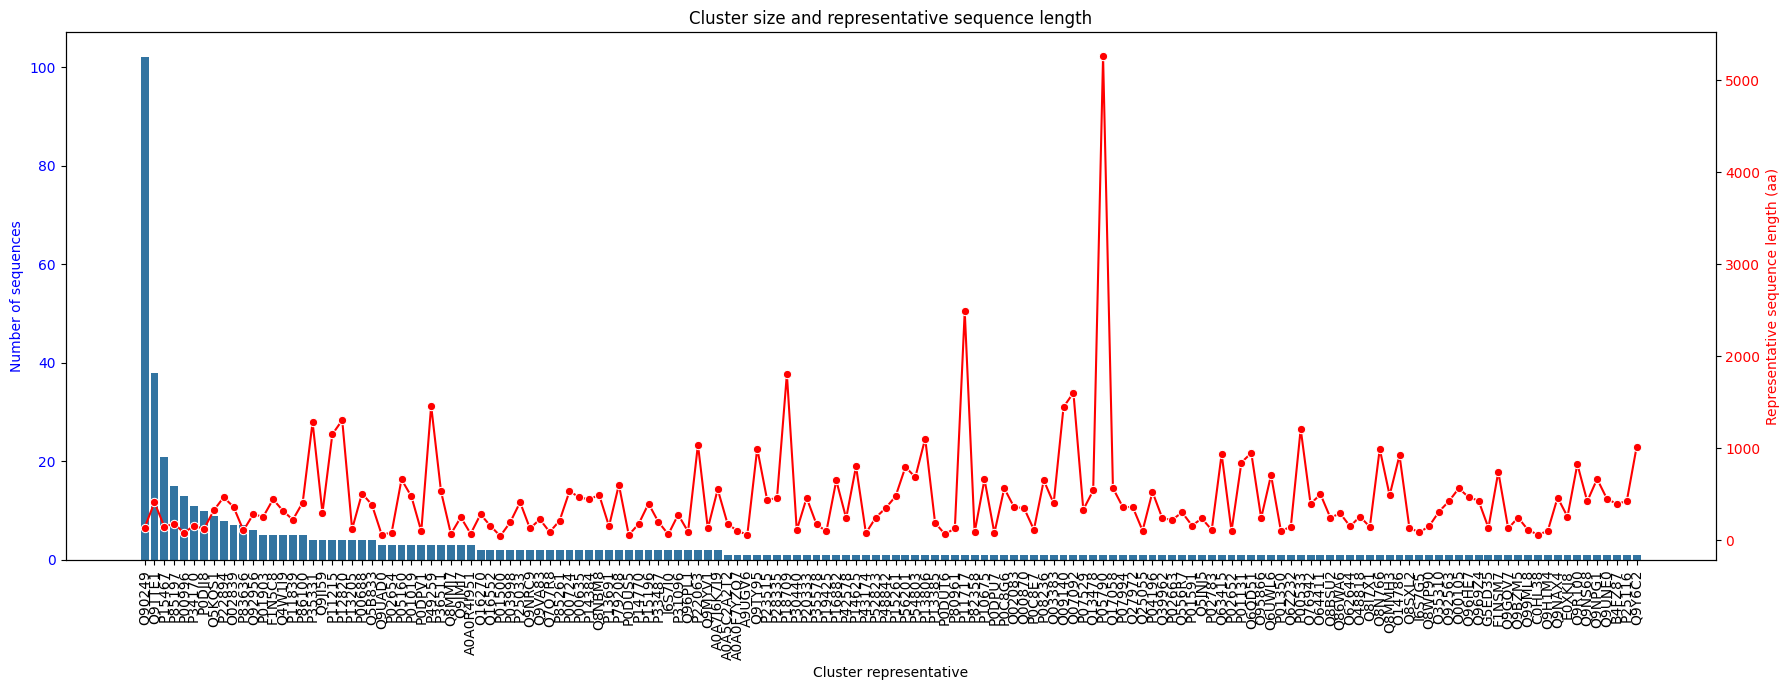

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read MMseqs2 cluster mapping
df = pd.read_csv(
    "pos_clustered_cluster.tsv",
    sep="\t",
    header=None,
    names=["Representative", "Sequence"]
)

# Number of sequences in each cluster
cluster_sizes = (
    df.groupby("Representative")
      .size()
      .reset_index(name="Number_of_sequences")
      .sort_values("Number_of_sequences", ascending=False)
      .reset_index(drop=True)
)

# Add representative sequence lengths
lengths = {}
with open("pos_clustered_rep_seq.fasta") as f:
    current_id = None
    seq = []

    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if current_id:
                lengths[current_id] = len("".join(seq))
            current_id = line.split("|")[1]
            seq = []
        else:
            seq.append(line)

    if current_id:
        lengths[current_id] = len("".join(seq))

cluster_sizes["Rep_Length"] = cluster_sizes["Representative"].map(lengths)

# Show every 10th cluster
plot_df = cluster_sizes.iloc[::7].copy()

# Plot
fig, ax1 = plt.subplots(figsize=(18, 7))

# Blue: number of sequences
sns.barplot(
    data=plot_df,
    x="Representative",
    y="Number_of_sequences",
    ax=ax1
)

ax1.set_xlabel("Cluster representative")
ax1.set_ylabel("Number of sequences", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.tick_params(axis="x", rotation=90)

# Red: representative sequence length
ax2 = ax1.twinx()

sns.lineplot(
    data=plot_df,
    x="Representative",
    y="Rep_Length",
    ax=ax2,
    color="red",
    marker="o"
)

ax2.set_ylabel("Representative sequence length (aa)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Cluster size and representative sequence length")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2551/2657092600.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"{abs(int(x))}" for x in ticks])


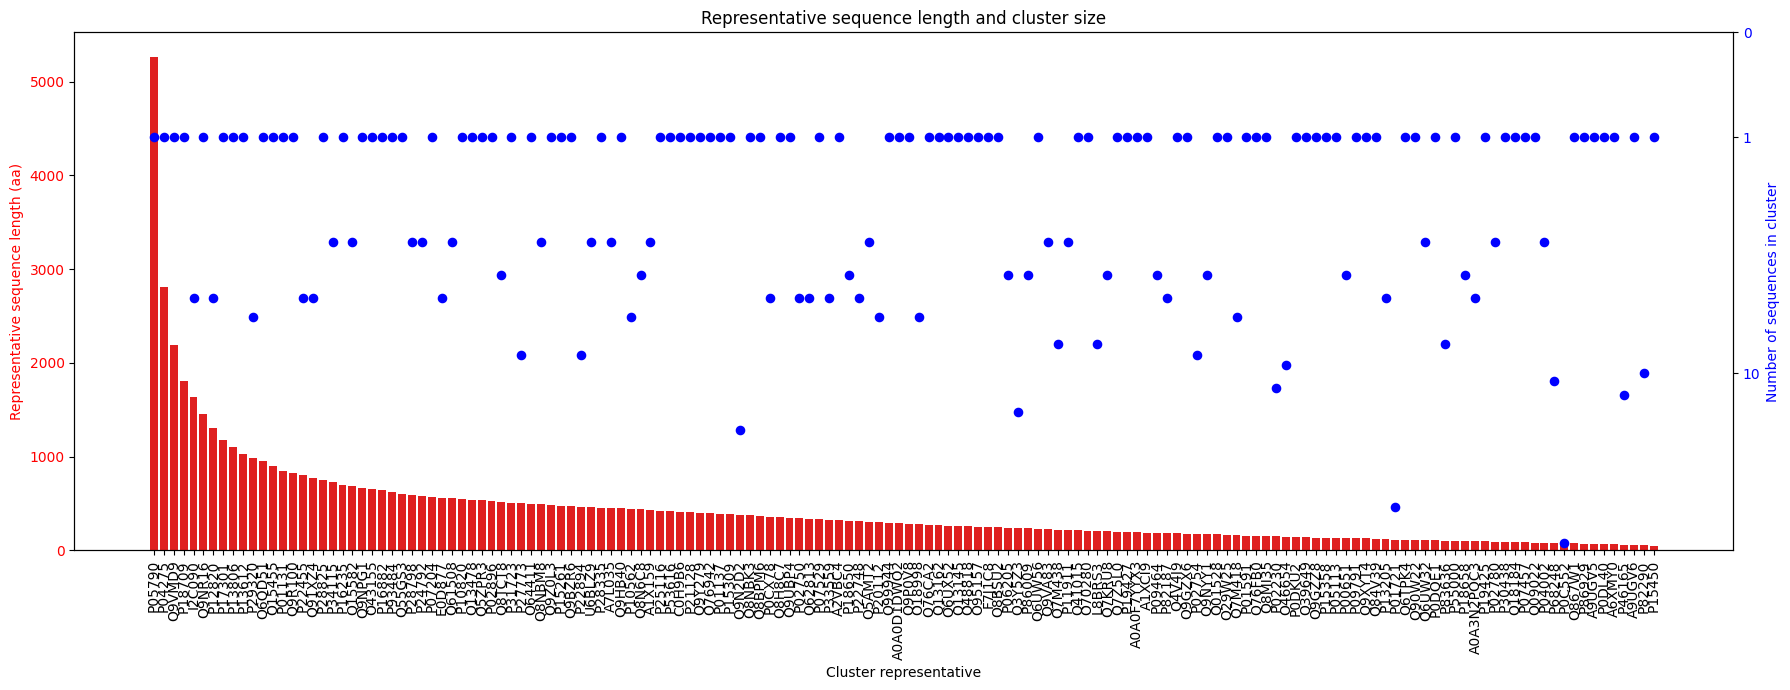

In [40]:
# Sort by representative sequence length: longest → shortest
cluster_sizes = (
    df.groupby("Representative")
      .size()
      .reset_index(name="Number_of_sequences")
)

cluster_sizes["Rep_Length"] = cluster_sizes["Representative"].map(lengths)

cluster_sizes = (
    cluster_sizes
    .sort_values("Rep_Length", ascending=False)
    .reset_index(drop=True)
)

# Show every 10th cluster
plot_df = cluster_sizes.iloc[::7].copy()

# Plot
fig, ax1 = plt.subplots(figsize=(18, 7))

# Red: representative sequence length
sns.barplot(
    data=plot_df,
    x="Representative",
    y="Rep_Length",
    ax=ax1,
    color="red"
)

ax1.set_xlabel("Cluster representative")
ax1.set_ylabel("Representative sequence length (aa)", color="red")
ax1.tick_params(axis="y", labelcolor="red")
ax1.tick_params(axis="x", rotation=90)

# Blue: number of sequences in cluster, downward
ax2 = ax1.twinx()

ax2.scatter(
    range(len(plot_df)),
    -plot_df["Number_of_sequences"],
    color="blue",
    s=35
)
ax2.set_yscale("symlog")

ax2.set_ylabel("Number of sequences in cluster", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

# Make downward axis labels positive
max_size = plot_df["Number_of_sequences"].max()
ax2.set_ylim(-max_size * 1.1, 0)

ticks = ax2.get_yticks()
ax2.set_yticklabels([f"{abs(int(x))}" for x in ticks])

plt.title("Representative sequence length and cluster size")
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

df = pd.read_csv("training_5fold_cv_master.tsv", sep="\t")

# 1. Check contingency table across folds and labels
contingency = pd.crosstab(df["CV_Fold"], df["Label"], margins=True)
contingency.columns = ["Negative (0)", "Positive (1)", "Total"]

# 2. Compute ratio of Negatives to Positives per fold
ratio_per_fold = (contingency["Negative (0)"] / contingency["Positive (1)"]).round(2)
contingency["Neg:Pos Ratio"] = ratio_per_fold

print("=== 5-FOLD CROSS-VALIDATION BALANCE CHECK ===")
print(contingency)

# 3. Check for unexpected null values in fold assignments
missing_folds = df["CV_Fold"].isna().sum()
print(f"\nMissing fold assignments: {missing_folds}")

=== 5-FOLD CROSS-VALIDATION BALANCE CHECK ===
         Negative (0)  Positive (1)  Total  Neg:Pos Ratio
CV_Fold                                                  
0                1404           170   1574           8.26
1                1403           170   1573           8.25
2                1403           170   1573           8.25
3                1403           169   1572           8.30
4                1403           169   1572           8.30
All              7016           848   7864           8.27

Missing fold assignments: 0


In [14]:
df

,Q12396,Accession,Label,Set,CV_Fold,O74740
0,O35310,O35310,1,Training,0,NaN
1,P08887,P08887,1,Training,1,NaN
2,P0C1X6,P0C1X6,1,Training,2,NaN
3,Q8VCS0,Q8VCS0,1,Training,3,NaN
4,Q9TY95,Q9TY95,1,Training,4,NaN
...,...,...,...,...,...,...
7859,NaN,Q587E3,0,Training,1,Q587E3
7860,NaN,P93306,0,Training,2,P93306
7861,NaN,Q04964,0,Training,3,Q04964
7862,NaN,Q17604,0,Training,4,Q17604
